Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [3]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Expression_Genes_DESeq.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\DEA_Genes_DESeq.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\SraRunTable_Tanaka2014.csv"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [4]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,GSM1249124,GSM1249126,GSM1249130,GSM1249122,GSM1249123,GSM1249128,GSM1249129
0,DDX11L2,1,0,5,4,2,0,62
1,WASH7P,1,23,2,13,6,10,61
2,ENSG00000238009,1,5,18,0,4,13,6
3,ENSG00000268903,5,0,0,20,4,0,2
4,ENSG00000269981,8,0,7,6,3,1,18


DEA - Import

In [5]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,SNHG25,228.654057,-7.896077,0.557900,-14.153209,1.784257e-45,3.426487e-41
1,ZNF208,1590.202728,7.599687,0.686737,11.066374,1.826428e-28,1.753736e-24
2,RMRP,369.549814,-6.744027,0.656027,-10.280106,8.663203e-25,5.545605e-21
3,ARF3,112.240828,-8.057205,0.814095,-9.897135,4.283725e-23,2.056616e-19
4,UBE3A,117.812691,-4.778360,0.490799,-9.735885,2.119636e-22,8.141096e-19


Volcano plot

Classification
Non-significant    17217
Down-regulated      1282
Up-regulated         705
Name: count, dtype: int64
Total tes:
23256


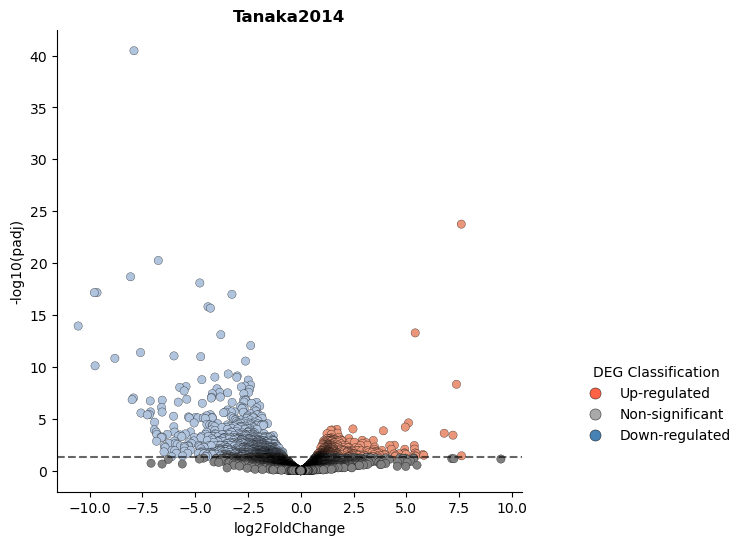

In [6]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Tanaka2014', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    print('Total tes:')
    print(len(expression_df))

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [7]:
# Variables
genes = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data

clinical_data['Condition'] = clinical_data['mutation'].apply(lambda x: 'WT' if x == 'no' else 'RTT')

clinical_data.loc[ clinical_data['Run'].isin(['SRR1015689', 'SRR1015687', 'SRR1015691', 'SRR1015690']) |
                  (clinical_data['mutation'] == 'no')
                  ]

clinical_data.loc[clinical_data['treatment'] != 'no', 'Condition'] = 'shMECP2'
print(clinical_data.columns)
clinical_data = clinical_data[['Sample Name', 'mutation', 'Run', 'Condition']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample Name', how = 'left')

pca_df.head()




   GSM1249124  GSM1249126  GSM1249130  GSM1249122  GSM1249123  GSM1249128  \
0    0.097796    0.000000    0.110089    0.322487    0.173255    0.000000   
1    0.097796    0.681582    0.045049    0.859234    0.467593    0.590254   
2    0.097796    0.177959    0.362286    0.000000    0.327917    0.728717   
3    0.433693    0.000000    0.000000    1.171478    0.327917    0.000000   
4    0.642561    0.000000    0.151875    0.460194    0.252658    0.071146   

   GSM1249129  
0    1.056310  
1    1.044179  
2    0.143365  
3    0.049388  
4    0.393343  
Index(['Run', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample',
       'Bytes', 'cell_type', 'Center Name', 'Consent', 'DATASTORE filetype',
       'DATASTORE provider', 'DATASTORE region', 'Experiment',
       'GEO_Accession (exp)', 'Instrument', 'LibraryLayout',
       'LibrarySelection', 'LibrarySource', 'mutation', 'Organism', 'PASSAGE',
       'Platform', 'ReleaseDate', 'create_date', 'version', 'Sample Name',
       '

,Sample Name,PC1,PC2,mutation,Run,Condition
0,GSM1249124,102.220181,-49.670244,no,SRR1015685,WT
1,GSM1249126,-133.754904,19.655367,X487W,SRR1015687,RTT
2,GSM1249130,-65.917474,-27.408451,R306C,SRR1015691,RTT
3,GSM1249122,104.553635,-42.057602,no,SRR1015683,WT
4,GSM1249123,58.348206,-15.646100,no,SRR1015684,WT


PCA - Graph

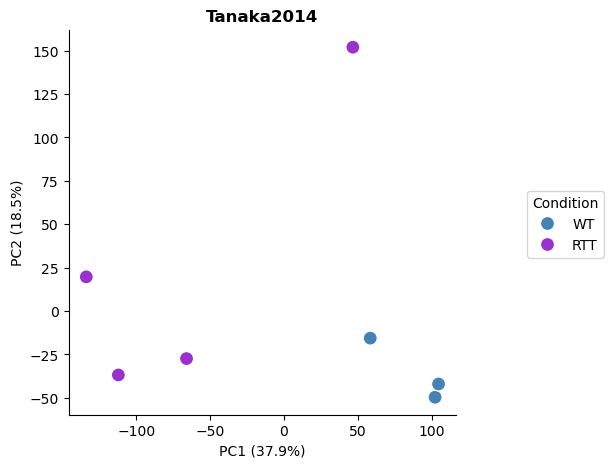

In [10]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Tanaka2014", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [9]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - Genes - Tanaka', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Genes')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`